# Regularization

### L1 Regularization 
$$
L_1 = \lambda~\sum_{m}~|w_m|
$$

### L2 Regularization 
$$
L_2 = \lambda~\sum_{m}~w_m^2
$$

Where $\lambda$ is the hyperparameter is how much regularization impact on loss. And where $w_m$ is the weights and biases.

```python
l1w = lambda_l1w * sum(abs(weights)) 
l1b = lambda_l1b * sum(abs(biases)) 
l2w = lambda_l2w * sum(weights**2) 
l2b = lambda_l2b * sum(biases**2) 
loss = data_loss + l1w + l1b + l2w + l2b
```

In [1]:
# imports 
import matplotlib.pyplot as plt
import numpy as np
import math
import nnfs
from nnfs.datasets import spiral_data

# Initialize Current Code

In [3]:
class Activation_ReLU: 
    def forward(self, inputs): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 

class Loss: 
    def calculate(self, output, y): 
        sample_losses = self.forward(output, y) 
        data_loss = np.mean(sample_losses) 
        return data_loss 
 
class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[ 
                range(samples), 
                y_true 
            ] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum( 
                y_pred_clipped * y_true, 
                axis=1 
            ) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 

class Activation_Softmax: 
    def forward(self, inputs): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
 
class Activation_Softmax_Loss_CategoricalCrossentropy(): 
    def __init__(self): 
        self.activation = Activation_Softmax() 
        self.loss = Loss_CategoricalCrossentropy() 
 
    def forward(self, inputs, y_true): 
        self.activation.forward(inputs) 
        self.output = self.activation.output 
        return self.loss.calculate(self.output, y_true) 
 
    def backward(self, dvalues, y_true): 
 
        samples = len(dvalues) 
 
        if len(y_true.shape) == 2: 
            y_true = np.argmax(y_true, axis=1) 
 
        self.dinputs = dvalues.copy() 
        self.dinputs[range(samples), y_true] -= 1 
        self.dinputs = self.dinputs / samples 

class Optimizer_Adam: 
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
        self.epsilon = epsilon 
        self.beta_1 = beta_1 
        self.beta_2 = beta_2 
 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    def update_params(self, layer): 
 
        if not hasattr(layer, 'weight_cache'): 
            layer.weight_momentums = np.zeros_like(layer.weights) 
            layer.weight_cache = np.zeros_like(layer.weights) 
            layer.bias_momentums = np.zeros_like(layer.biases) 
            layer.bias_cache = np.zeros_like(layer.biases) 
 
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights 
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases 

        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2 
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2 

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
 
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon) 
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon) 
 
    def post_update_params(self): 
        self.iterations += 1 

# Applying Regularization in our current code

In [4]:
class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[range(samples), y_true] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 
    
    def regularization_loss(self, layer):
        regularization_loss = 0

        # integrate l1 regularizer here
        if layer.weight_regularizer_l1 > 0:
            regularization_loss += layer.weight_regularizer_l1 * np.sum(np.abs(layer.weights))
        if layer.bias_regularizer_l1 > 0:
            regularization_loss += layer.bias_regularizer_l1 * np.sum(np.abs(layer.biases))

        # integrate l2 regularizer here
        if layer.weight_regularizer_l2 > 0:
            regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights ** 2)
        if layer.bias_regularizer_l2 > 0:
            regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases ** 2)
        
        return regularization_loss

### Backwards Pass
L1 derivation:
$$
L_{1w} = \lambda \sum_{m} |w_m| \quad \rightarrow \quad L'_{1w} = \frac{\partial}{\partial w_m} \lambda \sum_{m} |w_m| = \lambda \frac{\partial}{\partial w_m} |w_m| = \boxed{\lambda \begin{cases} 1 & w_m > 0 \\ -1 & w_m < 0 \end{cases}}
$$

#### Pseudocode for L1 Backwards Pass
```python
weights ​= ​[[​0.2​, ​0.8​, ​-​0.5​, ​1​],  ​# now we have 3 sets of weights 
           ​[​0.5​, ​-​0.91​, ​0.26​, ​-​0.5​], 
           [​-​0.26​, ​-​0.27​, ​0.17​, ​0.87​]] 
dL1 ​= ​[]  ​# array of partial derivatives of L1 regularization 
for ​neuron ​in ​weights: 
    neuron_dL1 ​= ​[]  ​# derivatives related to one neuron 
    ​for ​weight ​in ​neuron: 
        ​if ​weight ​>= ​0​: 
            neuron_dL1.append(​1​) 
        ​else​: 
            neuron_dL1.append(​-​1​) 
    dL1.append(neuron_dL1) 
print​(dL1) 
 
 
>>> 
[[​1​, ​1​, ​-​1​, ​1​], [​1​, ​-​1​, ​1​, ​-​1​], [​-​1​, ​-​1​, ​1​, ​1​]]
```

L2 derivation:
$$
L_{2w} = \lambda \sum_{m} w_m^2 \quad \rightarrow \quad \frac{\partial L_{2w}}{\partial w_m} = \frac{\partial}{\partial w_m} \left[ \lambda \sum_{m} w_m^2 \right] =
$$

$$
= \lambda \frac{\partial}{\partial w_m} w_m^2 = \lambda \cdot 2w_m^{2-1} = \boxed{2\lambda w_m}
$$

In [5]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0, bias_regularizer_l1=0,
                 weight_regularizer_l2=0, bias_regularizer_l2=0):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

        # initialize here
        self.weight_regularizer_l1 = weight_regularizer_l1
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l2 = bias_regularizer_l2        

    def forward(self, inputs):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues) 
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)         

        # backwards pass
        # integrate l1 regularizer here
        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1
            self.dweights += self.weight_regularizer_l1 * dL1
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1

        # integrate l2 regularizer here
        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights
        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases

        self.dinputs = np.dot(dvalues, self.weights.T)

# Run model with dataset

In [10]:
X, y = spiral_data(samples=100, classes=3) 

learning_rate = 0.02
decay = 5e-7
dense1 = Layer_Dense(2, 512, weight_regularizer_l2=5e-4, 
                            bias_regularizer_l2=5e-4) 
activation1 = Activation_ReLU() 
dense2 = Layer_Dense(512, 3) 
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy() 
optimizer = Optimizer_Adam(learning_rate=learning_rate, decay=decay) 
loss_history, accuracy_history, learning_rate_history = [], [], []


for epoch in range(10001): 
    # Forward pass
    dense1.forward(X) 
    activation1.forward(dense1.output) 
    dense2.forward(activation1.output) 

    #
    data_loss = loss_activation.forward(dense2.output, y) 
    regularization_loss = loss_activation.loss.regularization_loss(dense1) + loss_activation.loss.regularization_loss(dense2) 
    loss = data_loss + regularization_loss 

    predictions = np.argmax(loss_activation.output, axis=1) 
    if len(y.shape) == 2: 
        y = np.argmax(y, axis=1) 
    accuracy = np.mean(predictions==y) 
 
    if not epoch % 1000: 
        print(f'epoch: {epoch}, ' + 
              f'acc: {accuracy:.3f}, ' + 
              f'loss: {loss:.3f} (' + 
              f'data_loss: {data_loss:.3f}, ' + 
              f'reg_loss: {regularization_loss:.3f}), ' + 
              f'lr: {optimizer.current_learning_rate}') 
 
    # Backward pass 
    loss_activation.backward(loss_activation.output, y) 
    dense2.backward(loss_activation.dinputs) 
    activation1.backward(dense2.dinputs) 
    dense1.backward(activation1.dinputs) 
 
    optimizer.pre_update_params() 
    optimizer.update_params(dense1) 
    optimizer.update_params(dense2) 
    optimizer.post_update_params() 
    
    loss_history.append(loss)
    accuracy_history.append(accuracy)
    learning_rate_history.append(optimizer.current_learning_rate)

epoch: 0, acc: 0.380, loss: 1.093 (data_loss: 1.088, reg_loss: 0.005), lr: 0.02
epoch: 1000, acc: 0.923, loss: 0.302 (data_loss: 0.217, reg_loss: 0.085), lr: 0.019990014987513734
epoch: 2000, acc: 0.937, loss: 0.255 (data_loss: 0.185, reg_loss: 0.069), lr: 0.019980029960054924
epoch: 3000, acc: 0.933, loss: 0.262 (data_loss: 0.184, reg_loss: 0.078), lr: 0.019970054902673444
epoch: 4000, acc: 0.940, loss: 0.223 (data_loss: 0.162, reg_loss: 0.061), lr: 0.019960089800444013
epoch: 5000, acc: 0.940, loss: 0.214 (data_loss: 0.156, reg_loss: 0.058), lr: 0.019950134638471142
epoch: 6000, acc: 0.933, loss: 0.240 (data_loss: 0.173, reg_loss: 0.067), lr: 0.019940189401889033
epoch: 7000, acc: 0.940, loss: 0.211 (data_loss: 0.156, reg_loss: 0.055), lr: 0.019930254075861523
epoch: 8000, acc: 0.943, loss: 0.197 (data_loss: 0.148, reg_loss: 0.049), lr: 0.019920328645582
epoch: 9000, acc: 0.943, loss: 0.206 (data_loss: 0.148, reg_loss: 0.058), lr: 0.019910413096273318
epoch: 10000, acc: 0.933, loss: 

# Validate with Test Dataset

We have a lower accuracy though expected with regularization, we know our model isn't overfitting.

In [11]:
# test dataset
X_test, y_test = spiral_data(samples=200,  classes=3) 

dense1.forward(X_test) 
activation1.forward(dense1.output) 
dense2.forward(activation1.output) 
loss = loss_activation.forward(dense2.output, y_test) 
predictions  =  np.argmax(loss_activation.output,  axis=1) 

if len(y_test.shape)  ==  2: 
    y_test  =  np.argmax(y_test,  axis=1) 
accuracy = np.mean(predictions==y_test) 
print(f'validation, acc:  {accuracy:.3f}, loss:  {loss:.3f}')

validation, acc:  0.823, loss:  0.578


# Initialize Fitted Data Function

In [12]:
def plot_decision_boundary(model_layers, X, y, resolution=0.02):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution),
        np.arange(y_min, y_max, resolution)
    )
    
    # Flatten mesh and predict
    Z_input = np.c_[xx.ravel(), yy.ravel()]
    
    # Forward pass through network
    dense1.forward(Z_input)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss_activation.forward(dense2.output, np.zeros((len(Z_input), 3)))
    
    # Get predictions
    Z = np.argmax(loss_activation.output, axis=1).reshape(xx.shape)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Contourf for decision boundaries
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', levels=2)
    
    # Scatter plot for actual data
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y if len(y.shape) == 1 else np.argmax(y, axis=1),
                        cmap='viridis', edgecolors='k', s=50, alpha=0.7)
    
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title('Neural Network Decision Boundaries')
    plt.colorbar(scatter, ax=ax, label='Class')
    plt.tight_layout()
    plt.show()

# Graph Data

Final Values: Loss 0.19835662855419542 Accuracy 0.9333333333333333 Learning Rate 0.019900497512437814
Learning Rate 0.02 Decay 5e-07


C:\Users\paolo\AppData\Local\Temp\ipykernel_24036\790645834.py:10: RuntimeWarning: divide by zero encountered in log
  negative_log_likelihoods = -np.log(correct_confidences)


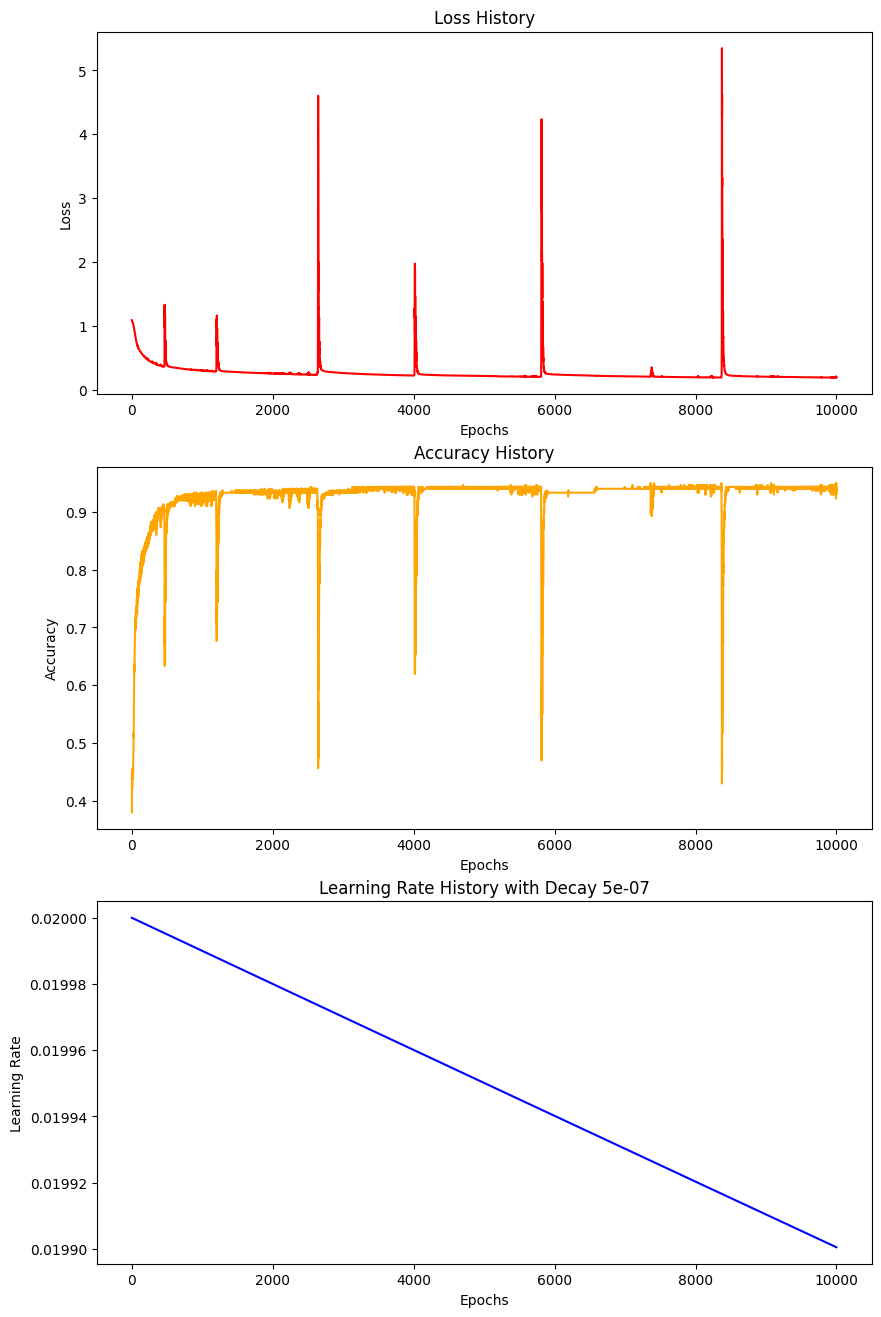

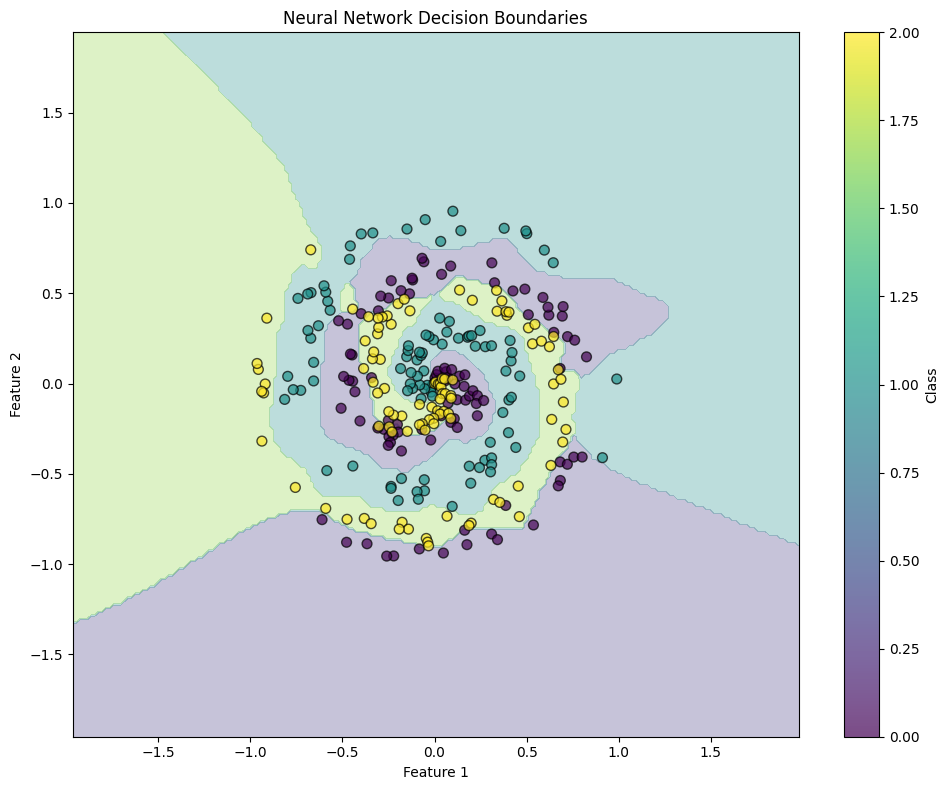

In [14]:
fig, axes = plt.subplots(nrows=3, figsize=(10, 16))

axes[0].set_title("Loss History")
axes[0].plot(loss_history, color="red")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].set_title("Accuracy History")
axes[1].plot(accuracy_history, color="orange")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")

axes[2].set_title(f"Learning Rate History with Decay {decay}")
axes[2].plot(learning_rate_history, color="blue")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Learning Rate")

print(f"Final Values: Loss {loss_history[-1]} Accuracy {accuracy_history[-1]} Learning Rate {learning_rate_history[-1]}")
print(f"Learning Rate {learning_rate} Decay {decay}")
plot_decision_boundary([dense1, activation1, dense2, loss_activation], X, y)
